# 1. Closed Queuing network simulation (17 pt)
Build a simulator to capture the following system and answer the questions below. A total of N=40 jobs circulate in different parts of the systems: CPU, disk, and resting area. There is one CPU and two disks, one slow and one fast. Each job starts at the CPU station and takes an average of 2 seconds. After CPU, a job fetches the data from the disk, needing an average of 3000 disk cycles. There are two possible choices of disks, fast and slow, which have a speed of 1000 cycles per second and 100 cycles per seconds, respectively. After the disk station, the job can rest for 15 seconds on average. The figure below gives an overview of the system:


![image](Queued.png)

The choices of distributions are up to you. You are welcomed to try different distributions to answer the following questions and assess the impact of different variants.


Questions:
(3p) What will be the maximal system throughput in terms of number of jobs, given two different load balancing strategies for sending jobs between the fast and slow disk? You need to come up with two load balancing strategies and compare them. 
(3p) What will the system throughput and average response time of a job be if a faster CPU is used? Say, CPU time is reduced to 1 seconds on average and the rest of the system remains the same.
(3p) What will the system throughput and average response time of a job be if a second fast disk is added? Again, you need to compare the throughput under two different load balancing strategies.
(3p) What will the system throughput and average response time of a job be if a faster CPU is used and a second fast disk is added? And, you use the better load balancing strategies out of two you propose in the first question?
(5pt) If you can answer all the above questions with different number of N and plot them in the following style:


![image](Graph.png)

In [21]:
# imports
import os
import sys
from contextlib import contextmanager, redirect_stdout
from typing import Generator

import matplotlib.pyplot as plt
import numpy as np
import simpy
from matplotlib.axes import Axes
from matplotlib.figure import Figure

RNG = np.random.default_rng(seed=0)

@contextmanager
def suppress_print():
    """Temporarily disable print statements."""
    with redirect_stdout(open(os.devnull, "w")):
        yield

In [22]:
# Closed Queueing Network Simulation
# Two-tier disk system (fast and slow) with load balancing

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)


class ClosedQueueNetwork:
    """Closed queueing network with CPU and two disks (fast/slow)."""
    
    def __init__(self, N_jobs: int = 40) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        self.N_jobs = N_jobs
        
        # Service time scale parameters
        self.beta_cpu = 2.0
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0

    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job in the closed network."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk phase: randomly select fast or slow (50/50)
            if RNG.random() < 0.5:
                # Fast disk
                with self.fast_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
            else:
                # Slow disk
                with self.slow_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))
            
            # Rest phase (think time)
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))

    def run(self, until: float = 1000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self


In [23]:
ClosedQueueNetwork(N_jobs=40).run(until=1000)

In [24]:
# Question 1: Load Balancing Strategy Comparison
# Closed queueing network with CPU and two disk types

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    """Closed queueing network with CPU and two disks (fast/slow)."""
    
    def __init__(self, N_jobs: int = 40, strategy: str = "random") -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        
        # Throughput tracking
        self.completed_cycles = 0
        
        # Utilization tracking
        self.cpu_busy_time = 0.0
        self.disk_fast_busy_time = 0.0
        self.disk_slow_busy_time = 0.0
        
        # Probability for proportional strategy
        self.fast_prob = 1000 / (1000 + 100)

    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                cpu_service = RNG.exponential(2.0)
                self.cpu_busy_time += cpu_service
                yield self.env.timeout(cpu_service)

            # Disk choice based on strategy
            use_fast = self._select_disk()

            # Disk service
            if use_fast:
                with self.fast_disk.request() as request:
                    yield request
                    disk_service = RNG.exponential(3.0)
                    self.disk_fast_busy_time += disk_service
                    yield self.env.timeout(disk_service)
            else:
                with self.slow_disk.request() as request:
                    yield request
                    disk_service = RNG.exponential(30.0)
                    self.disk_slow_busy_time += disk_service
                    yield self.env.timeout(disk_service)

            # Rest phase
            yield self.env.timeout(RNG.exponential(15.0))
            self.completed_cycles += 1

    def _select_disk(self) -> bool:
        """Select disk based on strategy. Returns True for fast disk."""
        if self.strategy == "random":
            return RNG.random() < 0.5
        elif self.strategy == "proportional":
            return RNG.random() < self.fast_prob
        elif self.strategy == "jsq":
            # Join-the-Shorter-Queue
            fast_len = len(self.fast_disk.queue)
            slow_len = len(self.slow_disk.queue)
            return fast_len <= slow_len
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        """Return throughput: completed cycles per unit time."""
        return self.completed_cycles / self.env.now

    def utilization(self) -> dict:
        """Return resource utilization."""
        total_time = self.env.now
        return {
            "cpu": self.cpu_busy_time / total_time,
            "disk_fast": self.disk_fast_busy_time / total_time,
            "disk_slow": self.disk_slow_busy_time / total_time,
        }


def question_1_comparison(
    N_values: list = None,
    n_reps: int = 5,
    sim_length: float = 100000,
) -> tuple:
    """Compare load balancing strategies across varying N."""
    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]
    
    strategies = ["random", "proportional", "jsq"]
    results = {s: [] for s in strategies}
    
    for strategy in strategies:
        for N in N_values:
            throughputs = []
            
            for _ in range(n_reps):
                net = ClosedQueueNetwork(N_jobs=N, strategy=strategy)
                net.run(until=sim_length)
                throughputs.append(net.system_throughput())
            
            results[strategy].append({
                "N": N,
                "mean": np.mean(throughputs),
                "std": np.std(throughputs),
                "min": np.min(throughputs),
                "max": np.max(throughputs),
            })
    
    # Identify best strategies
    max_throughputs = {
        s: max([r["mean"] for r in results[s]]) for s in strategies
    }
    sorted_strategies = sorted(strategies, key=lambda s: max_throughputs[s], reverse=True)
    best_two = sorted_strategies[:2]
    
    return results, max_throughputs, best_two


if __name__ == "__main__":
    results, max_thrs, best_strats = question_1_comparison()
    
    print("### Results Summary")
    print(f"Top Strategy:  {best_strats[0]} (Max X: {max_thrs[best_strats[0]]:.4f})")
    print(f"Runner Up:     {best_strats[1]} (Max X: {max_thrs[best_strats[1]]:.4f})")


### Results Summary
Top Strategy:  jsq (Max X: 0.3675)
Runner Up:     proportional (Max X: 0.3661)


In [25]:
# Question 2: Faster CPU Impact
# System throughput and average response time with CPU service time reduced to 1s.

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    """Closed queueing network with CPU and two disks (fast/slow)."""
    
    def __init__(self, N_jobs: int = 40, strategy: str = "jsq", cpu_mean: float = 1.0) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        self.fast_disk = simpy.Resource(self.env, capacity=1)
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        
        # Service time scale parameters
        self.beta_cpu = cpu_mean # Reduced to 1.0s for Q2
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        # Throughput tracking
        self.completed_cycles = 0
        
    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk choice based on JSQ (best strategy from Q1)
            use_fast = self._select_disk()

            # Disk service
            if use_fast:
                with self.fast_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
            else:
                with self.slow_disk.request() as request:
                    yield request
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            # Rest phase
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self) -> bool:
        """Select disk based on JSQ strategy."""
        fast_len = len(self.fast_disk.queue)
        slow_len = len(self.slow_disk.queue)
        return fast_len <= slow_len

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        """Return throughput: completed cycles per unit time."""
        return self.completed_cycles / self.env.now

    def average_response_time(self) -> float:
        """Calculate average response time using Little's Law: E[R] = N / X - Z"""
        X = self.system_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0.0

def question_2_analysis(N_values: list = None, n_reps: int = 5, sim_length: float = 100000) -> None:
    """Analyze throughput and response time with reduced CPU service time (1s)."""
    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]

    print("### Question 2: Faster CPU (1s mean)")
    print(f"Strategy: JSQ (Best from Q1)")
    print(f"{'N':>6} | {'Throughput (X)':>16} | {'Response Time (E[R])':>22}")
    print("-" * 50)
    
    for N in N_values:
        throughputs = []
        response_times = []
        
        for _ in range(n_reps):
            net = ClosedQueueNetwork(N_jobs=N, strategy="jsq", cpu_mean=1.0)
            net.run(until=sim_length)
            
            X = net.system_throughput()
            R = net.average_response_time()
            
            throughputs.append(X)
            response_times.append(R)
        
        avg_X = np.mean(throughputs)
        avg_R = np.mean(response_times)
        
        print(f"{N:>6} | {avg_X:>16.4f} | {avg_R:>22.2f}s")

if __name__ == "__main__":
    question_2_analysis()


### Question 2: Faster CPU (1s mean)
Strategy: JSQ (Best from Q1)
     N |   Throughput (X) |   Response Time (E[R])
--------------------------------------------------
    10 |           0.3067 |                  17.61s
    20 |           0.3640 |                  39.95s
    40 |           0.3674 |                  93.87s
    80 |           0.3661 |                 203.55s
   160 |           0.3671 |                 420.82s


In [26]:
# Question 3: Second Fast Disk Impact
# System throughput and average response time with 2 fast disks + 1 slow disk.
# Compare two load balancing strategies.

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    """Closed queueing network with CPU and multiple disks."""
    
    def __init__(
        self, 
        N_jobs: int = 40, 
        strategy: str = "jsq", 
        cpu_mean: float = 2.0,
        num_fast_disks: int = 1
    ) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        # Support multiple fast disks
        self.fast_disks = [
            simpy.Resource(self.env, capacity=1) 
            for _ in range(num_fast_disks)
        ]
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        self.num_fast_disks = num_fast_disks
        
        # Service time scale parameters
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        # Throughput tracking
        self.completed_cycles = 0
        
        # Probability for proportional strategy
        # fast_rate = 1/3, slow_rate = 1/30
        # total_rate = num_fast * (1/3) + 1/30
        fast_rate = 1.0 / 3.0
        slow_rate = 1.0 / 30.0
        total_rate = (num_fast_disks * fast_rate) + slow_rate
        self.fast_prob = (num_fast_disks * fast_rate) / total_rate
        
    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk selection
            selected_disk, is_fast = self._select_disk()

            # Disk service
            with selected_disk.request() as request:
                yield request
                if is_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            # Rest phase
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk(self) -> tuple:
        """Select disk based on strategy. Returns (disk_resource, is_fast)."""
        
        if self.strategy == "proportional":
            # Route based on service rate ratios
            if RNG.random() < self.fast_prob:
                # Pick random fast disk
                disk = self.fast_disks[RNG.integers(0, self.num_fast_disks)]
                return (disk, True)
            else:
                return (self.slow_disk, False)
                
        elif self.strategy == "jsq":
            # Join-the-Shorter-Queue: find shortest queue among ALL disks
            # Get all fast disk queue lengths
            fast_lens = [(len(d.queue), i) for i, d in enumerate(self.fast_disks)]
            slow_len = len(self.slow_disk.queue)
            
            # Find best fast disk
            best_fast_len, best_fast_idx = min(fast_lens, key=lambda x: x[0])
            
            # Compare best fast vs slow
            if best_fast_len <= slow_len:
                return (self.fast_disks[best_fast_idx], True)
            else:
                return (self.slow_disk, False)
        
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        """Return throughput: completed cycles per unit time."""
        return self.completed_cycles / self.env.now

    def average_response_time(self) -> float:
        """Calculate average response time using Little's Law: E[R] = N / X - Z"""
        X = self.system_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0.0


def question_3_analysis(
    N_values: list = None, 
    n_reps: int = 5, 
    sim_length: float = 100000
) -> None:
    """Compare throughput with 2 fast disks under two strategies."""
    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]

    strategies = ["proportional", "jsq"]
    
    print("### Question 3: Second Fast Disk Added")
    print("System: CPU (2s) + 2 Fast Disks (3s) + 1 Slow Disk (30s)\n")
    
    for strategy in strategies:
        print(f"Strategy: {strategy.upper()}")
        print(f"{'N':>6} | {'Throughput (X)':>16} | {'Response Time (E[R])':>22}")
        print("-" * 50)
        
        for N in N_values:
            throughputs = []
            response_times = []
            
            for _ in range(n_reps):
                net = ClosedQueueNetwork(
                    N_jobs=N, 
                    strategy=strategy, 
                    cpu_mean=2.0,
                    num_fast_disks=2
                )
                net.run(until=sim_length)
                
                X = net.system_throughput()
                R = net.average_response_time()
                
                throughputs.append(X)
                response_times.append(R)
            
            avg_X = np.mean(throughputs)
            avg_R = np.mean(response_times)
            
            print(f"{N:>6} | {avg_X:>16.4f} | {avg_R:>22.2f}s")
        
        print()

    # Comparison summary
    print("=" * 50)
    print("COMPARISON SUMMARY (N=40)")
    print("=" * 50)
    
    for strategy in strategies:
        throughputs = []
        for _ in range(n_reps):
            net = ClosedQueueNetwork(
                N_jobs=40, 
                strategy=strategy, 
                cpu_mean=2.0,
                num_fast_disks=2
            )
            net.run(until=sim_length)
            throughputs.append(net.system_throughput())
        
        avg_X = np.mean(throughputs)
        print(f"{strategy.upper():15s}: X = {avg_X:.4f}")


if __name__ == "__main__":
    question_3_analysis()


### Question 3: Second Fast Disk Added
System: CPU (2s) + 2 Fast Disks (3s) + 1 Slow Disk (30s)

Strategy: PROPORTIONAL
     N |   Throughput (X) |   Response Time (E[R])
--------------------------------------------------
    10 |           0.3590 |                  12.86s
    20 |           0.4790 |                  26.75s
    40 |           0.4991 |                  65.14s
    80 |           0.5006 |                 144.83s
   160 |           0.5002 |                 304.89s

Strategy: JSQ
     N |   Throughput (X) |   Response Time (E[R])
--------------------------------------------------
    10 |           0.3771 |                  11.52s
    20 |           0.4897 |                  25.84s
    40 |           0.4976 |                  65.39s
    80 |           0.4997 |                 145.09s
   160 |           0.4994 |                 305.39s

COMPARISON SUMMARY (N=40)
PROPORTIONAL   : X = 0.5008
JSQ            : X = 0.5004


In [27]:
# Question 4: Combined Improvements Impact
# System throughput and average response time with:
# - Faster CPU (1s)
# - 2 Fast Disks + 1 Slow Disk
# - Best Load Balancing Strategy (JSQ)

from typing import Generator
import numpy as np
import simpy

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    """Closed queueing network with CPU and multiple disks."""
    
    def __init__(
        self, 
        N_jobs: int = 40, 
        strategy: str = "jsq", 
        cpu_mean: float = 1.0,  # Faster CPU (1s)
        num_fast_disks: int = 2 # 2 Fast Disks
    ) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        # Support multiple fast disks
        self.fast_disks = [
            simpy.Resource(self.env, capacity=1) 
            for _ in range(num_fast_disks)
        ]
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        self.num_fast_disks = num_fast_disks
        
        # Service time scale parameters
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        # Throughput tracking
        self.completed_cycles = 0
        
    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk choice based on JSQ (best strategy from Q1)
            use_fast, disk_resource = self._select_disk_jsq()

            # Disk service
            with disk_resource.request() as request:
                yield request
                if use_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            # Rest phase
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk_jsq(self) -> tuple:
        """Select disk based on JSQ strategy. Returns (is_fast, disk_resource)."""
        # Get all fast disk queue lengths
        fast_lens = [(len(d.queue), i) for i, d in enumerate(self.fast_disks)]
        slow_len = len(self.slow_disk.queue)
        
        # Find best fast disk
        best_fast_len, best_fast_idx = min(fast_lens, key=lambda x: x[0])
        
        # Compare best fast vs slow
        if best_fast_len <= slow_len:
            return (True, self.fast_disks[best_fast_idx])
        else:
            return (False, self.slow_disk)

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        """Run simulation until specified time."""
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        """Return throughput: completed cycles per unit time."""
        return self.completed_cycles / self.env.now

    def average_response_time(self) -> float:
        """Calculate average response time using Little's Law: E[R] = N / X - Z"""
        X = self.system_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0.0

def question_4_analysis(N_values: list = None, n_reps: int = 5, sim_length: float = 100000) -> None:
    """Analyze throughput with combined improvements (Faster CPU + 2 Fast Disks)."""
    
    if N_values is None:
        N_values = [10, 20, 40, 80, 160]

    print("### Question 4: Combined Improvements")
    print("System: Faster CPU (1s) + 2 Fast Disks (3s) + 1 Slow Disk (30s)")
    print("Strategy: JSQ (Best from Q1)\n")
    
    print(f"{'N':>6} | {'Throughput (X)':>16} | {'Response Time (E[R])':>22}")
    print("-" * 50)
    
    for N in N_values:
        throughputs = []
        response_times = []
        
        for _ in range(n_reps):
            net = ClosedQueueNetwork(
                N_jobs=N, 
                strategy="jsq", 
                cpu_mean=1.0,     # Faster CPU
                num_fast_disks=2  # 2 Fast Disks
            )
            net.run(until=sim_length)
            
            X = net.system_throughput()
            R = net.average_response_time()
            
            throughputs.append(X)
            response_times.append(R)
        
        avg_X = np.mean(throughputs)
        avg_R = np.mean(response_times)
        
        print(f"{N:>6} | {avg_X:>16.4f} | {avg_R:>22.2f}s")

if __name__ == "__main__":
    question_4_analysis()


### Question 4: Combined Improvements
System: Faster CPU (1s) + 2 Fast Disks (3s) + 1 Slow Disk (30s)
Strategy: JSQ (Best from Q1)

     N |   Throughput (X) |   Response Time (E[R])
--------------------------------------------------
    10 |           0.4282 |                   8.35s
    20 |           0.6438 |                  16.07s
    40 |           0.7004 |                  42.11s
    80 |           0.6990 |                  99.45s
   160 |           0.7007 |                 213.36s


Running simulations...
Scenario 1...
Scenario 2...
Scenario 3...
Scenario 4...

Plots saved as 'q5_final_plots.png'


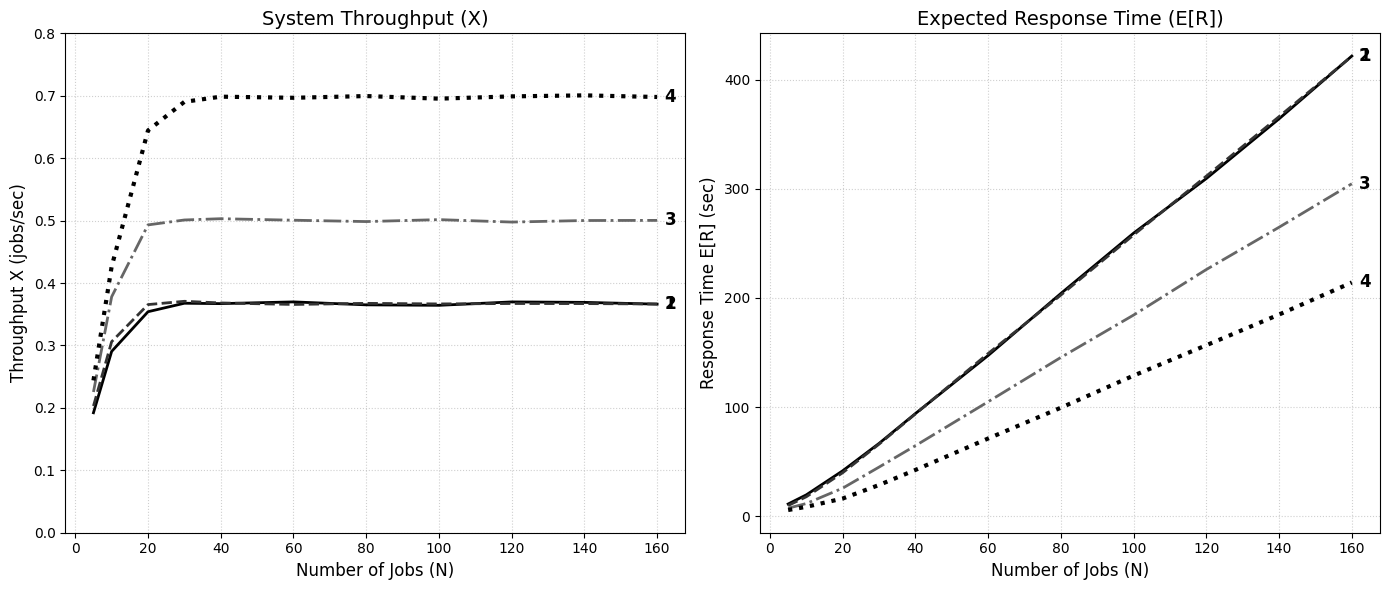

In [28]:
# Question 5: Performance Plots
# Plots for Throughput (X) vs N and Response Time (E[R]) vs N
# Comparison of all 4 scenarios

from typing import Generator
import numpy as np
import simpy
import matplotlib.pyplot as plt

RNG = np.random.default_rng(seed=0)

class ClosedQueueNetwork:
    """Closed queueing network with CPU and multiple disks."""
    
    def __init__(
        self, 
        N_jobs: int = 40, 
        strategy: str = "jsq", 
        cpu_mean: float = 2.0,
        num_fast_disks: int = 1
    ) -> None:
        self.env = simpy.Environment()
        self.cpu = simpy.Resource(self.env, capacity=1)
        self.slow_disk = simpy.Resource(self.env, capacity=1)
        
        # Support multiple fast disks
        self.fast_disks = [
            simpy.Resource(self.env, capacity=1) 
            for _ in range(num_fast_disks)
        ]
        
        self.N_jobs = N_jobs
        self.strategy = strategy
        self.num_fast_disks = num_fast_disks
        
        # Service time scale parameters
        self.beta_cpu = cpu_mean
        self.beta_fast_disk = 3.0
        self.beta_slow_disk = 30.0
        self.beta_rest = 15.0
        
        # Throughput tracking
        self.completed_cycles = 0
        
    def job_generator(self, job_id: int) -> Generator:
        """Process loop for a single job."""
        while True:
            # CPU phase
            with self.cpu.request() as request:
                yield request
                yield self.env.timeout(RNG.exponential(scale=self.beta_cpu))

            # Disk choice based on JSQ
            disk_resource, is_fast = self._select_disk_jsq()

            # Disk service
            with disk_resource.request() as request:
                yield request
                if is_fast:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_fast_disk))
                else:
                    yield self.env.timeout(RNG.exponential(scale=self.beta_slow_disk))

            # Rest phase
            yield self.env.timeout(RNG.exponential(scale=self.beta_rest))
            self.completed_cycles += 1

    def _select_disk_jsq(self) -> tuple:
        """Select disk based on JSQ strategy. Returns (disk_resource, is_fast)."""
        fast_lens = [(len(d.queue), i) for i, d in enumerate(self.fast_disks)]
        slow_len = len(self.slow_disk.queue)
        
        best_fast_len, best_fast_idx = min(fast_lens, key=lambda x: x[0])
        
        if best_fast_len <= slow_len:
            return (self.fast_disks[best_fast_idx], True)
        else:
            return (self.slow_disk, False)

    def run(self, until: float = 100000) -> "ClosedQueueNetwork":
        for i in range(self.N_jobs):
            self.env.process(self.job_generator(i))
        self.env.run(until=until)
        return self

    def system_throughput(self) -> float:
        return self.completed_cycles / self.env.now

    def average_response_time(self) -> float:
        X = self.system_throughput()
        if X > 0:
            return (self.N_jobs / X) - self.beta_rest
        return 0.0

def generate_plots():
    # Define N values for smooth curves
    N_values = [5, 10, 20, 30, 40, 60, 80, 100, 120, 140, 160]
    sim_length = 50000
    n_reps = 3
    
    # Define scenarios
    scenarios = [
        {"id": "1", "label": "1. Baseline (2s CPU, 1 Disk)",   "cpu": 2.0, "fast": 1},
        {"id": "2", "label": "2. Fast CPU (1s CPU, 1 Disk)",   "cpu": 1.0, "fast": 1},
        {"id": "3", "label": "3. 2 Fast Disks (2s CPU, 2 Disks)", "cpu": 2.0, "fast": 2},
        {"id": "4", "label": "4. Combined (1s CPU, 2 Disks)",  "cpu": 1.0, "fast": 2}
    ]
    
    results = {s["id"]: {"X": [], "R": []} for s in scenarios}
    
    print("Running simulations...")
    for sc in scenarios:
        print(f"Scenario {sc['id']}...")
        for N in N_values:
            thrs = []
            resps = []
            for _ in range(n_reps):
                net = ClosedQueueNetwork(
                    N_jobs=N, 
                    strategy="jsq", 
                    cpu_mean=sc["cpu"],
                    num_fast_disks=sc["fast"]
                )
                net.run(until=sim_length)
                thrs.append(net.system_throughput())
                resps.append(net.average_response_time())
            
            results[sc["id"]]["X"].append(np.mean(thrs))
            results[sc["id"]]["R"].append(np.mean(resps))

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Styles for lines matching the requested image style (thick lines, simple labels)
    styles = {
        "1": {"color": "black", "linestyle": "-", "linewidth": 2},
        "2": {"color": "#333333", "linestyle": "--", "linewidth": 2},
        "3": {"color": "#666666", "linestyle": "-.", "linewidth": 2},
        "4": {"color": "#000000", "linestyle": ":", "linewidth": 3}
    }

    # Plot 1: Throughput (X)
    for sid in ["1", "2", "3", "4"]:
        ax1.plot(N_values, results[sid]["X"], label=sid, **styles[sid])
        # Add label at the end of the line
        ax1.text(N_values[-1]+2, results[sid]["X"][-1], sid, fontsize=12, va='center', fontweight='bold')

    ax1.set_title("System Throughput (X)", fontsize=14)
    ax1.set_xlabel("Number of Jobs (N)", fontsize=12)
    ax1.set_ylabel("Throughput X (jobs/sec)", fontsize=12)
    ax1.set_ylim(0, 0.8)  # Set limit slightly above max (0.7)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Plot 2: Response Time (E[R])
    for sid in ["1", "2", "3", "4"]:
        ax2.plot(N_values, results[sid]["R"], label=sid, **styles[sid])
        # Add label at the end of the line
        ax2.text(N_values[-1]+2, results[sid]["R"][-1], sid, fontsize=12, va='center', fontweight='bold')

    ax2.set_title("Expected Response Time (E[R])", fontsize=14)
    ax2.set_xlabel("Number of Jobs (N)", fontsize=12)
    ax2.set_ylabel("Response Time E[R] (sec)", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig('q5_final_plots.png', dpi=1000)
    print("\nPlots saved as 'q5_final_plots.png'")

if __name__ == "__main__":
    generate_plots()
